# Пункт 2. Выделение риск-факторов и описательная статистика

Тетрадка реализует пункт 2 задания по рыночному риску:
выделить риск-факторы портфеля, **сократить их число с помощью PCA / факторного
анализа** (п. 2.a), при необходимости досчитать недостающие данные (п. 2.b),
визуализировать историю и построить описательную статистику — корреляции,
тяжесть хвостов, тренд/сезонность/стационарность (п. 2.c).

Исходные данные собраны в пункте 1 (см. `data/` и `data_documentation.md`).
Вся тяжёлая логика вынесена в `utils/factors.py`, `utils/diagnostics.py`,
`utils/pca_tools.py`.

## 2.0 Портфель и отображение «инструмент → риск-фактор»

Портфель:
* **5 ОФЗ** (по 10 млн руб.) — процентный риск;
* **10 акций** (по 1 млн руб.) — долевой риск;
* **валюта** — 100 млн руб. в USD и 100 млн руб. в EUR — валютный риск.

| Подпортфель | Что реально движет стоимостью | Выбранные риск-факторы |
|---|---|---|
| Облигации | Вся кривая доходности (ОФЗ переоцениваются дисконтированием известных выплат) | Кривая бескупонной доходности (КБД), 12 сроков → **PCA → 3 фактора** (уровень/наклон/кривизна) |
| Акции | Совместное (рыночное) + идиосинкратическое движение цен | Лог-доходности акций → **PCA / факторный анализ** (рыночный фактор + остаточные) |
| Валюта | Курсы RUB к USD и EUR | Лог-доходности **USD/RUB** и **EUR/RUB** |

**Критическое обсуждение выбора (кратко, подробно — в выводах):**
* Для облигаций риск-фактор — **кривая целиком**, а не цены самих ОФЗ: цены —
  производные от кривой и купонного расписания, моделировать надо первопричину.
* **Индекс РТС не берём отдельным фактором** — он почти точно равен индексу
  МосБиржи, пересчитанному в доллары (показано ниже corr≈0.996), то есть линейная
  комбинация уже выбранных факторов.
* **Индекс МосБиржи** не берём как самостоятельный фактор — это линейная комбинация
  акций, его роль воспроизводит первая главная компонента акций (проверяем ниже).
* **Brent** не входит в портфель напрямую; он — косвенный драйвер нефтяных акций,
  поэтому в набор факторов портфеля не включаем, но анализируем его связь с акциями.
* Работаем с **приращениями** (лог-доходности, изменения ставок), а не уровнями —
  уровни нестационарны (проверяем тестами), PCA по нестационарным уровням некорректен.

In [8]:
# --- Настройка окружения ---
import sys, warnings
from pathlib import Path
import pyarrow
import fastparquet


PROJ = Path.cwd()
if not (PROJ / "utils").exists() and (PROJ.parent / "src").exists():
    PROJ = PROJ.parent
sys.path.insert(0, str(PROJ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")           # глушим InterpolationWarning от KPSS и т.п.
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110

from src import config as C
from src.risk_factors import factors as F
from src.risk_factors import diagnostics as D
from src.risk_factors import pca_tools as P

np.random.seed(C.RANDOM_SEED)
pd.options.io.parquet.engine = 'fastparquet'
panels = F.load_panels()
print({k: v.shape for k, v in panels.items()})

{'stock_px': (1271, 12), 'bond_px': (1271, 10), 'yields': (1256, 12), 'fx_px': (1237, 2), 'brent': (1270, 1), 'index_px': (1254, 2)}


## 2.b Подготовка данных: сплиты, разрывы, переход к приращениям

Перед выделением факторов чиним известные дефекты сырых цен (иначе они исказят и
PCA, и статистику хвостов):
1. **Сплиты акций** — день дробления даёт ложный «обвал» цены в N раз. Находим
   автоматически и делаем ряд непрерывным (back-adjust).
2. **Длинные календарные разрывы** — прежде всего остановка торгов на MOEX
   28.02–24.03.2022. Доходность «через разрыв» — не однодневная, исключаем её.
3. Переходим к **лог-доходностям** цен и **изменениям ставок** (в б.п.).

In [9]:
# 1) Сплиты: детектируем и корректируем
splits = F.detect_splits(panels["stock_px"])
print("Найденные сплиты (реальные корпоративные события):")
display(splits)
stock_px_adj, _ = F.adjust_splits(panels["stock_px"], splits)

# Единый торговый календарь MOEX (по дням, когда торговался широкий рынок акций).
# Курсы и кривую ЦБ протягиваем на этот календарь (официальный курс действует до
# следующей публикации) — иначе праздники ЦБ выбивали бы ~20% наблюдений.
master = stock_px_adj.dropna(how="all").index
fx_lvl    = F.to_trading_calendar(panels["fx_px"], master)
yield_lvl = F.to_trading_calendar(panels["yields"], master)

# 2)+3) Лог-доходности и изменения ставок (с занулением через длинные разрывы)
stock_ret = F.log_returns(stock_px_adj)
fx_ret    = F.log_returns(fx_lvl)
brent_ret = F.log_returns(F.to_trading_calendar(panels["brent"], master))
index_ret = F.log_returns(panels["index_px"])
dY        = F.yield_changes(yield_lvl)                  # изменения КБД, б.п.

n_gap = int((~F.mask_calendar_gaps(stock_px_adj)).sum())
print(f"\nТорговых дней в общем календаре: {len(master)}")
print(f"Исключено доходностей через длинные разрывы (вкл. остановку биржи-2022): {n_gap}")
print("Макс |дневная лог-доходность| акций после корректировки на сплиты:",
      round(float(np.nanmax(np.abs(stock_ret.values))), 3),
      "(до корректировки был ~ -4.6 = падение в 100 раз у GMKN)")

Найденные сплиты (реальные корпоративные события):


,TICKER,DATE,price_ratio,approx_split
0,GMKN,2024-04-08,0.0102,98
1,PLZL,2025-03-27,0.0982,10



Торговых дней в общем календаре: 1253
Исключено доходностей через длинные разрывы (вкл. остановку биржи-2022): 2
Макс |дневная лог-доходность| акций после корректировки на сплиты: 0.363 (до корректировки был ~ -4.6 = падение в 100 раз у GMKN)


## 2.c Визуализация истории риск-факторов

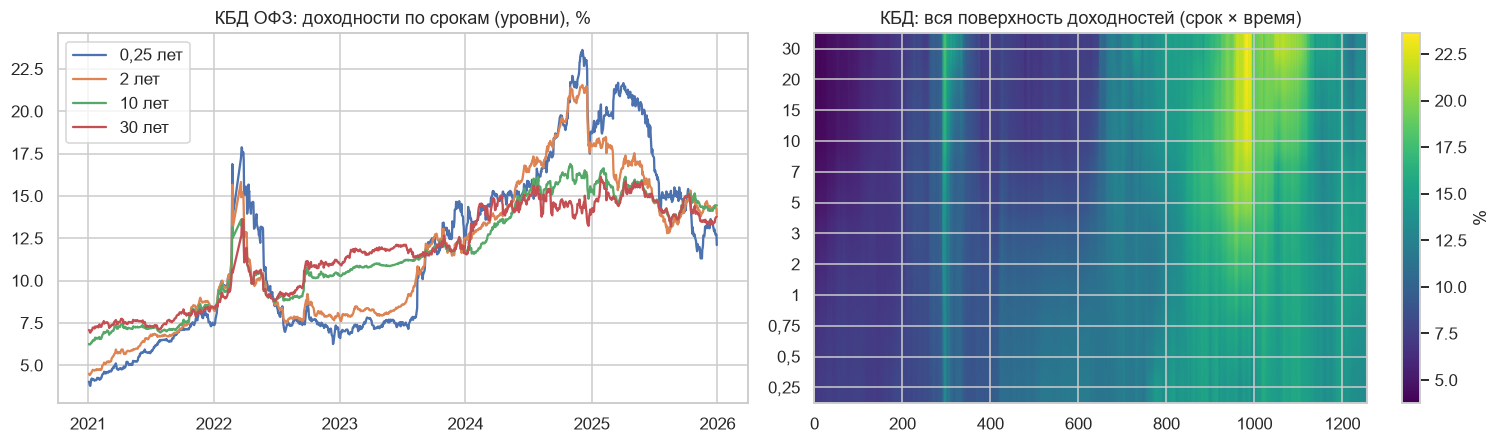

In [10]:
# Кривая доходности во времени: несколько сроков
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for t in ["0,25", "2", "10", "30"]:
    ax[0].plot(panels["yields"].index, panels["yields"][t], label=f"{t} лет")
ax[0].set_title("КБД ОФЗ: доходности по срокам (уровни), %"); ax[0].legend()
# Тепловая карта всей кривой
im = ax[1].imshow(panels["yields"].T.values, aspect="auto", cmap="viridis",
                  extent=[0, len(panels["yields"]), 0, len(F.TENOR_YEARS)])
ax[1].set_yticks(np.arange(len(F.TENOR_LABELS))+0.5); ax[1].set_yticklabels(F.TENOR_LABELS)
ax[1].set_title("КБД: вся поверхность доходностей (срок × время)")
plt.colorbar(im, ax=ax[1], label="%"); plt.tight_layout(); plt.show()

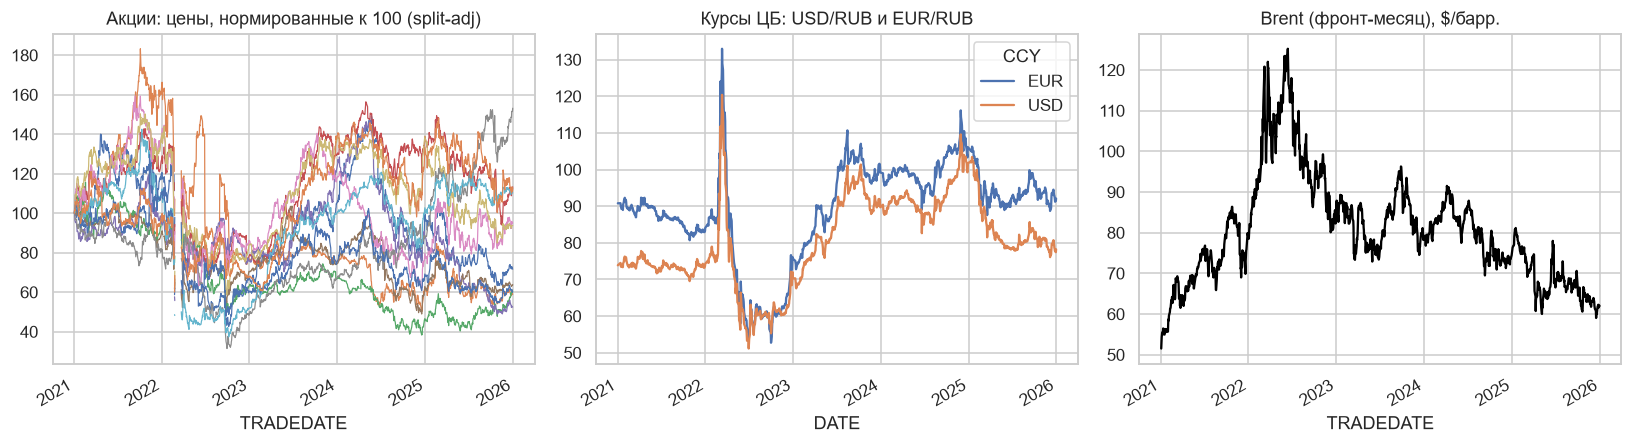

In [11]:
# Акции (нормированные к 100, с корректировкой на сплиты), валюта, нефть
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
norm = stock_px_adj / stock_px_adj.bfill().iloc[0] * 100
norm.plot(ax=ax[0], legend=False, lw=0.8)
ax[0].set_title("Акции: цены, нормированные к 100 (split-adj)")
panels["fx_px"].plot(ax=ax[1])
ax[1].set_title("Курсы ЦБ: USD/RUB и EUR/RUB")
panels["brent"].plot(ax=ax[2], legend=False, color="black")
ax[2].set_title("Brent (фронт-месяц), $/барр.")
plt.tight_layout(); plt.show()

## 2.a PCA кривой доходности → уровень / наклон / кривизна

PCA считаем по **изменениям** ставок (ковариация — единицы одинаковые, б.п.).
Три первые компоненты традиционно интерпретируются как уровень, наклон и кривизна.

Доля объяснённой дисперсии: {'PC1': 0.7453, 'PC2': 0.1413, 'PC3': 0.0689} | суммарно 3 ФК: 0.9555


,interpretation
PC1,level (уровень)
PC2,slope (наклон)
PC3,curvature (кривизна)


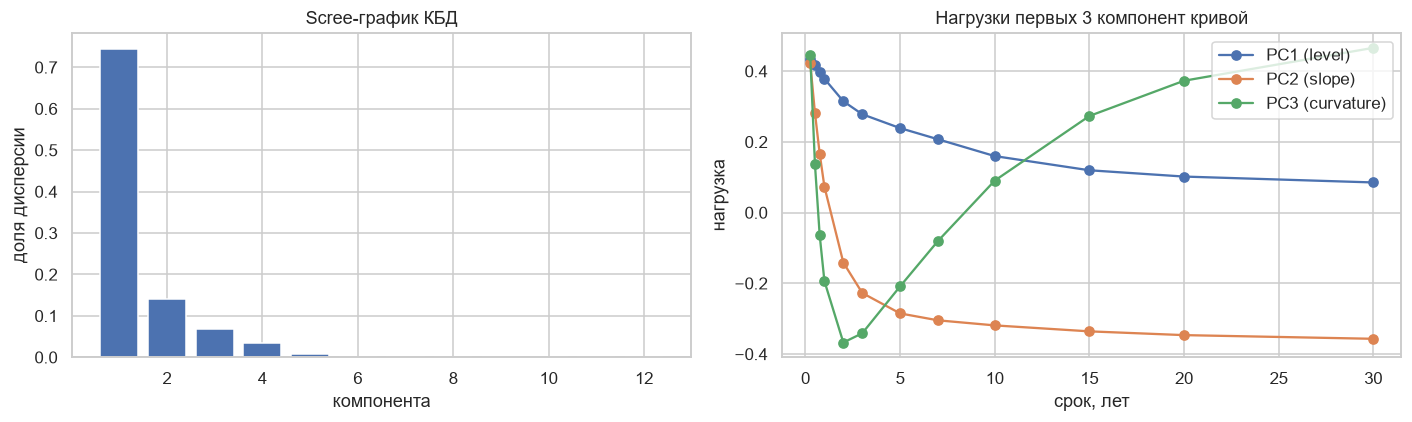

In [12]:
scree_y = P.full_scree(dY)
model_y, scores_y, load_y, evr_y = P.pca_on_changes(dY, n_components=3)
print("Доля объяснённой дисперсии:", evr_y.round(4).to_dict(),
      "| суммарно 3 ФК:", round(evr_y.sum(), 4))
display(P.interpret_curve_pcs(load_y))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(range(1, len(scree_y)+1), scree_y.values)
ax[0].set_title("Scree-график КБД"); ax[0].set_xlabel("компонента"); ax[0].set_ylabel("доля дисперсии")
for pc, name in zip(load_y.columns, ["level","slope","curvature"]):
    ax[1].plot(F.TENOR_YEARS, load_y[pc], marker="o", label=f"{pc} ({name})")
ax[1].set_xlabel("срок, лет"); ax[1].set_ylabel("нагрузка"); ax[1].legend()
ax[1].set_title("Нагрузки первых 3 компонент кривой"); plt.tight_layout(); plt.show()

## 2.a PCA / факторный анализ доходностей акций

Доходности стандартизуем (разные волатильности) и берём PCA по корреляциям.
Число факторов выбираем по критерию Кайзера (собственное число > 1) и по
накопленной дисперсии. Проверяем, что первая компонента — «рыночный» фактор
(сравниваем с доходностью индекса МосБиржи).

Критерий Кайзера: компонент с с.ч.>1 = 1; берём k = 3
Накопленная дисперсия: {'PC1': np.float64(0.539), 'PC2': np.float64(0.607), 'PC3': np.float64(0.663), 'PC4': np.float64(0.712), 'PC5': np.float64(0.757), 'PC6': np.float64(0.801)}
corr(PC1 акций, доходность IMOEX) = 0.821  -> PC1 это рыночный фактор


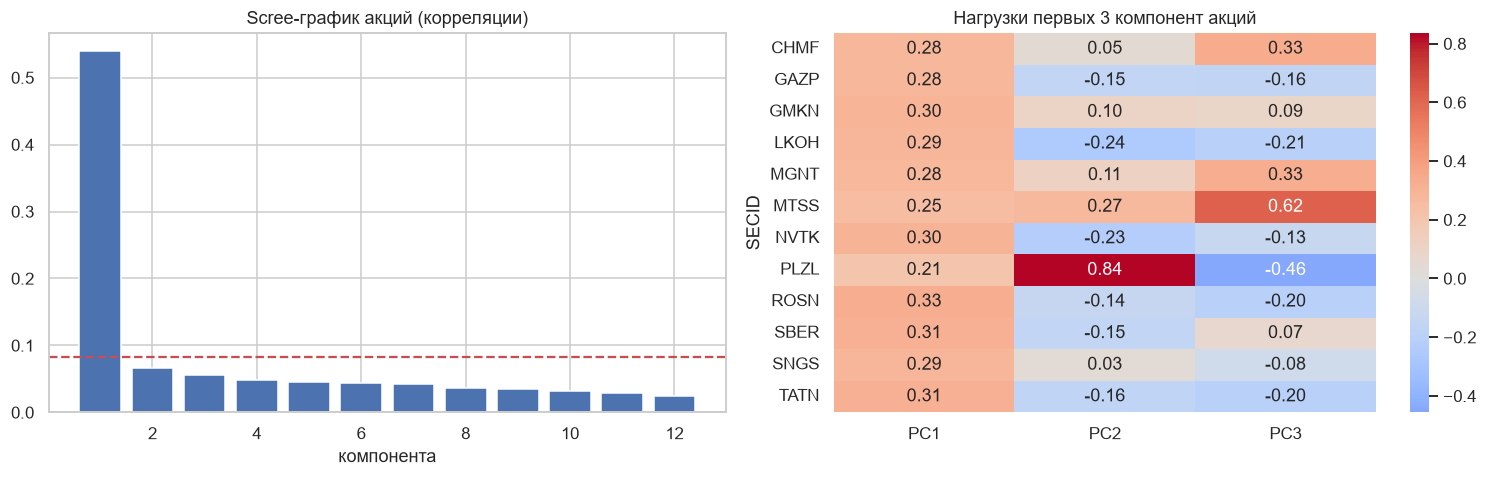

In [13]:
eq = stock_ret.dropna()
scree_e = P.full_scree(eq, standardize=True)
# Критерий Кайзера: собственные числа корреляц. матрицы > 1
eigvals = scree_e.values * eq.shape[1]
k_kaiser = int((eigvals > 1).sum())
k = max(3, k_kaiser)                      # берём не меньше 3 для содержательности
print(f"Критерий Кайзера: компонент с с.ч.>1 = {k_kaiser}; берём k = {k}")
print("Накопленная дисперсия:", {f"PC{i+1}": round(scree_e.head(i+1).sum(),3) for i in range(min(6,len(scree_e)))})

model_e, scores_e, load_e, evr_e = P.pca_on_changes(eq, n_components=k, standardize=True)

# PC1 vs доходность индекса МосБиржи — проверка «рыночности»
imoex_ret = index_ret["IMOEX"].reindex(scores_e.index)
corr_pc1_imoex = scores_e["PC1"].corr(imoex_ret)
print(f"corr(PC1 акций, доходность IMOEX) = {corr_pc1_imoex:.3f}  -> PC1 это рыночный фактор")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].bar(range(1, len(scree_e)+1), scree_e.values); ax[0].axhline(1/eq.shape[1], ls="--", color="r")
ax[0].set_title("Scree-график акций (корреляции)"); ax[0].set_xlabel("компонента")
sns.heatmap(load_e, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[1])
ax[1].set_title(f"Нагрузки первых {k} компонент акций")
plt.tight_layout(); plt.show()

## Валютные и товарные факторы: проверка избыточности РТС и роли Brent

Показываем количественно, почему **РТС** и **Brent** не входят в финальный набор.

In [14]:
# РТС ~ IMOEX в долларах: отношение уровней индексов должно повторять USD/RUB
piv = panels["index_px"].join(panels["fx_px"], how="inner").dropna()
ratio = piv["IMOEX"] / piv["RTSI"]
print(f"corr( IMOEX/RTSI , USD/RUB ) = {ratio.corr(piv['USD']):.3f}  -> РТС избыточен")

# Brent сильнее всего коррелирует с нефтегазовыми акциями
common = stock_ret.join(brent_ret, how="inner").dropna()
bcorr = common.corr()["BRENT"].drop("BRENT").sort_values(ascending=False)
print("\nКорреляция доходности Brent с акциями (топ-5):")
print(bcorr.head(5).round(3).to_string())
print("Вывод: Brent — драйвер нефтяных бумаг; в портфеле прямой позиции нет, "
      "поэтому отдельным фактором не берём (его влияние уже в факторах акций).")

corr( IMOEX/RTSI , USD/RUB ) = 0.996  -> РТС избыточен

Корреляция доходности Brent с акциями (топ-5):
TATN    0.137
LKOH    0.134
ROSN    0.123
SNGS    0.090
PLZL    0.088
Вывод: Brent — драйвер нефтяных бумаг; в портфеле прямой позиции нет, поэтому отдельным фактором не берём (его влияние уже в факторах акций).


## 2.c Корреляции риск-факторов

Собираем финальный набор факторов-приращений и смотрим корреляционную матрицу.

Итоговая матрица риск-факторов: (1235, 8)


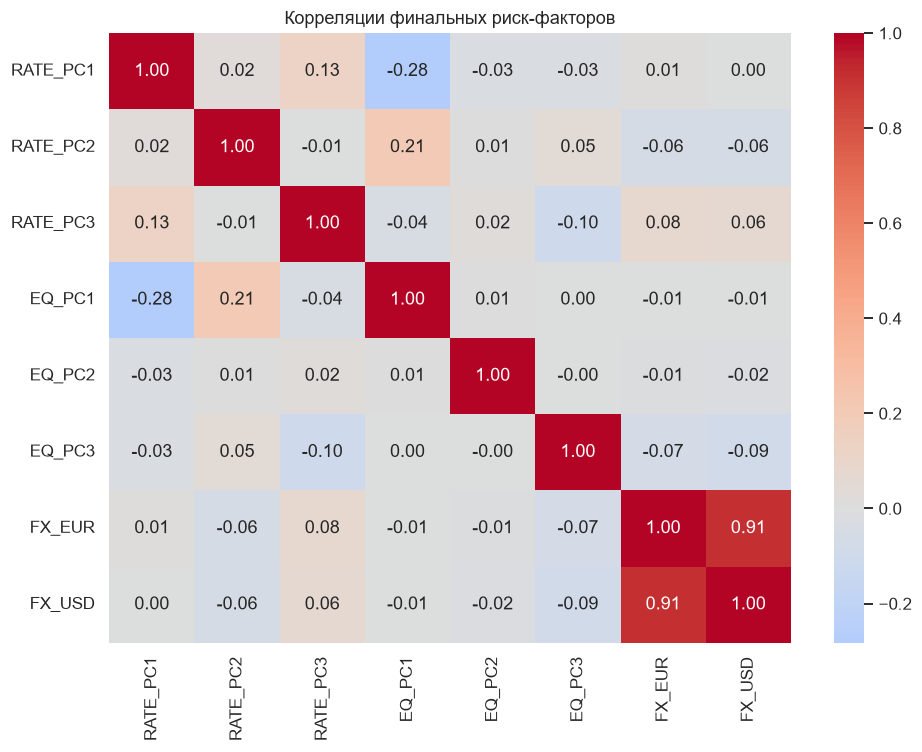

In [15]:
# Финальный набор риск-факторов (приращения), выровненный по общему календарю
rate_f = scores_y.add_prefix("RATE_")                       # 3 фактора кривой
eq_f   = scores_e.add_prefix("EQ_")                         # k факторов акций
fx_f   = fx_ret.rename(columns={"USD": "FX_USD", "EUR": "FX_EUR"})
aligned = F.align_on_common_dates(rate_f, eq_f, fx_f)
risk_factors = pd.concat(aligned, axis=1).dropna()
print("Итоговая матрица риск-факторов:", risk_factors.shape)

plt.figure(figsize=(9, 7))
sns.heatmap(risk_factors.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляции финальных риск-факторов"); plt.tight_layout(); plt.show()

## 2.c Тяжесть хвостов распределений

Для каждого фактора: эксцесс, тест Жарка–Бера (H0: нормальность), число степеней
свободы t-Стьюдента (меньше → тяжелее) и хвостовой индекс Хилла.

,std,skew,exc_kurt,JB_p,t_dof,hill_alpha
series,,,,,,
RATE_PC1,50.899,-3.974,50.388,0.0,2.058,2.114
RATE_PC2,27.478,0.460,7.932,0.0,2.199,2.668
RATE_PC3,18.904,0.393,8.713,0.0,2.372,2.757
EQ_PC1,2.545,-0.822,10.350,0.0,3.263,3.061
EQ_PC2,0.895,0.409,5.172,0.0,4.733,3.754
EQ_PC3,0.822,0.316,14.343,0.0,3.761,2.663
FX_EUR,0.012,0.245,16.723,0.0,1.041,2.570
FX_USD,0.012,0.565,19.754,0.0,1.045,2.804


Везде JB_p≈0 -> нормальность отвергается; избыточный эксцесс >> 0; t_dof мал, alpha Хилла ~2-4 -> ХВОСТЫ ТЯЖЁЛЫЕ (важно для выбора модели в п.3).


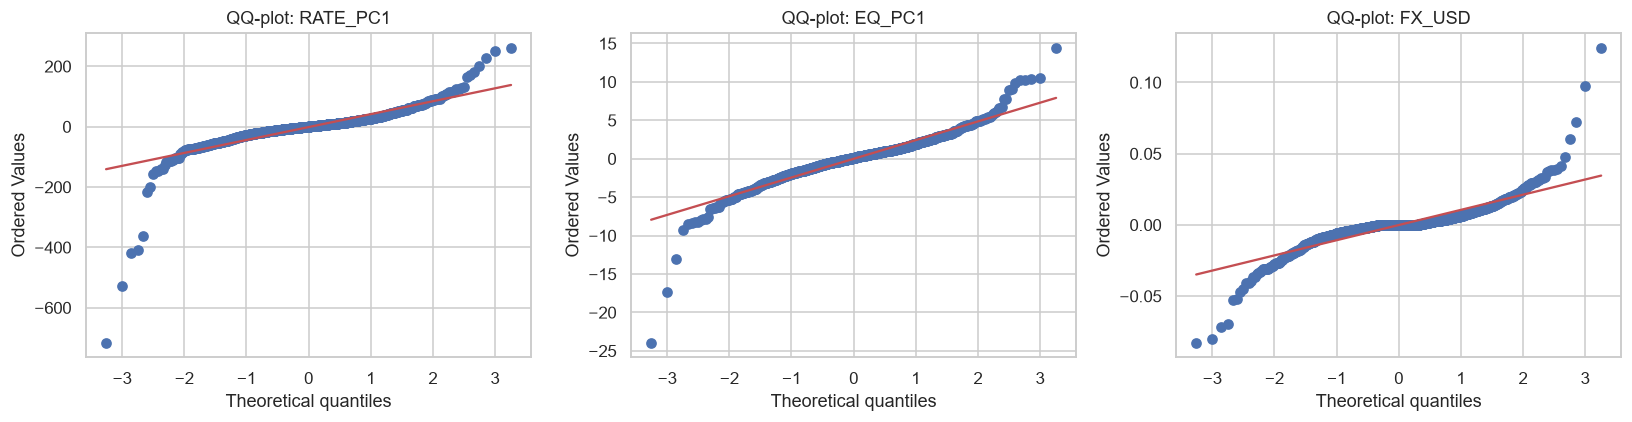

In [16]:
tt = D.tail_table(risk_factors)
display(tt[["std","skew","exc_kurt","JB_p","t_dof","hill_alpha"]].round(3))
print("Везде JB_p≈0 -> нормальность отвергается; избыточный эксцесс >> 0; "
      "t_dof мал, alpha Хилла ~2-4 -> ХВОСТЫ ТЯЖЁЛЫЕ (важно для выбора модели в п.3).")

# QQ-графики против нормали для нескольких факторов
from scipy import stats
sel = ["RATE_PC1", "EQ_PC1", "FX_USD"]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, c in zip(ax, sel):
    stats.probplot(risk_factors[c].dropna(), dist="norm", plot=a); a.set_title(f"QQ-plot: {c}")
plt.tight_layout(); plt.show()

## 2.c Тренд, сезонность, стационарность

Сравниваем стационарность **уровней** и **приращений** (ADF + KPSS), раскладываем
ряд на тренд/сезон/остаток (STL) и проверяем недельную сезонность доходностей.

In [17]:
# Стационарность: уровни (нестационарны) vs приращения (стационарны)
levels = pd.concat([
    panels["yields"]["10"].rename("yield_10y_level"),
    np.log(panels["brent"]["BRENT"]).rename("log_brent_level"),
    np.log(panels["fx_px"]["USD"]).rename("log_usd_level"),
], axis=1)
changes = pd.concat([
    dY["10"].rename("yield_10y_chg"),
    brent_ret["BRENT"].rename("brent_ret"),
    fx_ret["USD"].rename("usd_ret"),
], axis=1)
print("УРОВНИ:"); display(D.stationarity_table(levels))
print("ПРИРАЩЕНИЯ:"); display(D.stationarity_table(changes))

УРОВНИ:


,ADF_p,KPSS_p,verdict
series,,,
yield_10y_level,0.5553,0.01,нестационарен
log_brent_level,0.1993,0.01,нестационарен
log_usd_level,0.3308,0.01,нестационарен


ПРИРАЩЕНИЯ:


,ADF_p,KPSS_p,verdict
series,,,
yield_10y_chg,0.0,0.1,стационарен
brent_ret,0.0,0.1,стационарен
usd_ret,0.0,0.1,стационарен


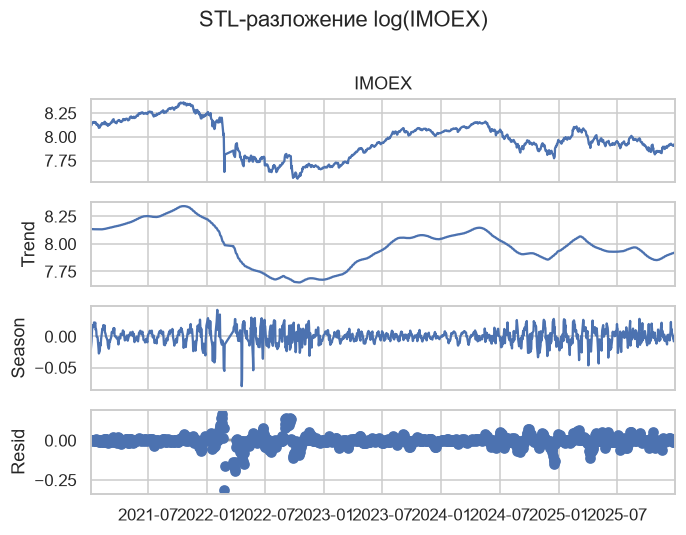

Средняя доходность и волатильность факторов по дням недели:


,mean,std
Пн,-0.33606,12.50473
Вт,0.80087,10.87262
Ср,-0.58160,12.12255
Чт,-0.42796,11.73754
Пт,-0.17520,15.08347
Сб,4.10094,17.03265


In [18]:
# STL-разложение уровня индекса МосБиржи (тренд + сезон + остаток)
from statsmodels.tsa.seasonal import STL
s = np.log(panels["index_px"]["IMOEX"].dropna())
res = STL(s, period=21, robust=True).fit()       # период ~ торговый месяц
res.plot(); plt.suptitle("STL-разложение log(IMOEX)", y=1.01); plt.tight_layout(); plt.show()

# Недельная сезонность доходностей факторов
wk = D.weekday_seasonality(risk_factors)
print("Средняя доходность и волатильность факторов по дням недели:")
display(wk.round(5))

## Сохранение финального набора риск-факторов

Сохраняем матрицу факторов и нагрузки PCA — они понадобятся в пунктах 3–5
(модели динамики, переоценка портфеля, оценка VaR/ES).

In [19]:
risk_factors.to_parquet(C.DATA_DIR / "risk_factors.parquet")
load_y.to_parquet(C.DATA_DIR / "rate_pca_loadings.parquet")
load_e.to_parquet(C.DATA_DIR / "equity_pca_loadings.parquet")
print("Сохранено:")
print("  risk_factors.parquet        ", risk_factors.shape, "->", list(risk_factors.columns))
print("  rate_pca_loadings.parquet   ", load_y.shape)
print("  equity_pca_loadings.parquet ", load_e.shape)

Сохранено:
  risk_factors.parquet         (1235, 8) -> ['RATE_PC1', 'RATE_PC2', 'RATE_PC3', 'EQ_PC1', 'EQ_PC2', 'EQ_PC3', 'FX_EUR', 'FX_USD']
  rate_pca_loadings.parquet    (12, 3)
  equity_pca_loadings.parquet  (12, 3)


## Критические выводы по пункту 2

**Выбор риск-факторов.**
* **Облигации → кривая (КБД), сжатая PCA до 3 факторов** (уровень/наклон/кривизна),
  объясняющих ~95% дисперсии изменений ставок. Это стандартный и экономически
  осмысленный результат; репрезентация устойчива.
* **Акции → PCA по корреляциям доходностей.** Первая компонента — **рыночный фактор**
  (высокая корреляция с индексом МосБиржи). Однако акции сжимаются **хуже** кривой:
  PC1 объясняет лишь ~半 дисперсии, остальное — идиосинкратический риск, который
  «не складывается» в малое число факторов (это честное ограничение, а не дефект).
  Поэтому в п. 4–5 индивидуальные доходности акций сохраняются для переоценки, а
  рыночные компоненты используются для структуры зависимостей.
* **Валюта → USD/RUB и EUR/RUB** (2 фактора). Они сильно скоррелированы между собой —
  это надо учесть в совместной модели (п. 3).
* **Исключены:** РТС (≈ IMOEX в долларах, corr≈0.996 с USD), отдельный фактор IMOEX
  (= комбинация акций), Brent (косвенный драйвер, прямой позиции в портфеле нет).

**Описательная статистика (влияет на выбор модели в п. 3).**
* **Хвосты тяжёлые** у всех факторов (избыточный эксцесс ≫ 0, JB отвергает нормальность,
  малое t_dof, индекс Хилла ~2–4) → нормальное распределение неадекватно, нужны
  распределения с тяжёлыми хвостами (t-Стьюдента) и/или модели волатильности (GARCH).
* **Уровни нестационарны, приращения стационарны** (ADF+KPSS согласованы) → моделируем
  именно приращения.
* **Сильной календарной сезонности нет** (недельный эффект мал); в ценах есть тренды и
  кластеризация волатильности (видно по STL-остатку) — аргумент в пользу
  GARCH-подобной динамики.

**Данные (п. 2.b).** Досчитаны/исправлены: лог-доходности и изменения ставок;
скорректированы сплиты GMKN (≈100:1, 2024) и PLZL (10:1, 2025); исключены
доходности через остановку торгов на MOEX (фев–мар 2022) и длинные праздники.